In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler

In [ ]:
def data_preprocess(rawdata: pd.DataFrame, spec_dict):
    categorical_features_values, continuous_features_values, list_drop = spec_dict.values()
    data = pd.concat([rawdata])
    data.drop(list_drop,axis=1,inplace=True, errors='ignore')
    
    # convert cat values to integer and limit categorical values
    cols_cat = data.select_dtypes(exclude=[np.number]).columns
    if cols_cat.any():
        for feat in cols_cat: 
            if data[feat].nunique()>categorical_features_values:
                data[feat] = np.where(data[feat].isin(data[feat].value_counts().head(categorical_features_values).index), data[feat], '-')
            
            data[feat] = data[feat].astype('category')
            data[feat] = data[feat].cat.codes

    og_samples = data[data.columns[:-1]]

    # clamping continuous values
    data_num = data.select_dtypes(include=[np.number])
    for feat in data_num.columns:
        if data_num[feat].max()>10*data_num[feat].median() :
            data[feat] = np.where(data[feat]<data[feat].quantile(0.95), data[feat], data[feat].quantile(0.95))


    # unskew data applying log
    data_num = data.select_dtypes(include=[np.number])
    for feature in data_num.columns:
        if data_num[feature].nunique()>continuous_features_values:
            if data_num[feature].min()==0:
                data[feature] = np.log(data[feature]+1)
            else:
                data[feature] = np.log(data[feature])


    # from bool features to int
    # bool_cols = samples.select_dtypes(include=bool).columns
    # if(len(bool_cols)):
    #     samples[bool_cols] = samples[bool_cols].astype(int)
    
    # split features and labels
    samples = data[data.columns[:-1]]
    labels = data[data.columns[-1]]

    # standardize float column
    # scaler = StandardScaler()
    # data_num = samples.select_dtypes(include=np.number)
    # samples[data_num.columns] = scaler.fit_transform(samples[data_num.columns])

    return og_samples, samples

### Data import and cleaning 

In [16]:
dict = {
    'categorical_features_values': 6,
    'continuous_features_values': 50,
    'list_drop': [
        'id',
        'attack_cat'
    ]
}

data_tr = pd.read_csv('../datasets/UNSW_NB15_training-set.csv', delimiter=',')
rawdata, processed_data = data_preprocess(data_tr, dict)

assert  rawdata.columns.equals(processed_data.columns)

/tmp/ipykernel_57305/686283719.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples[data_float.columns] = scaler.fit_transform(samples[data_float.columns])
/tmp/ipykernel_57305/686283719.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples[data_num.columns] = scaler.fit_transform(samples[data_num.columns])


In [17]:
res_folder='metric_plots/features_results'
for feat in rawdata.columns:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(rawdata[feat].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[0].set_title(f'rawdata avg {rawdata[feat].mean():.4f} mdn {rawdata[feat].median():.6f}')
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)
    axes[1].hist(processed_data[feat].dropna(), bins=30, edgecolor="black", alpha=0.7)
    axes[1].set_title(f'preprocessed avg {processed_data[feat].mean():.4f} mdn {processed_data[feat].median():.6f}')
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)
    fig.suptitle(f'Feature: {feat}', fontsize=16)
     
    res_subfolder = 'float_feats' if rawdata[feat].dtype == np.float64 else 'int_feats'
    plt.savefig(f'{res_folder}/{res_subfolder}/{feat}')
    # plt.show()
    fig.clear()

plt.clf()

/tmp/ipykernel_57305/3056327309.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))


<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

...

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

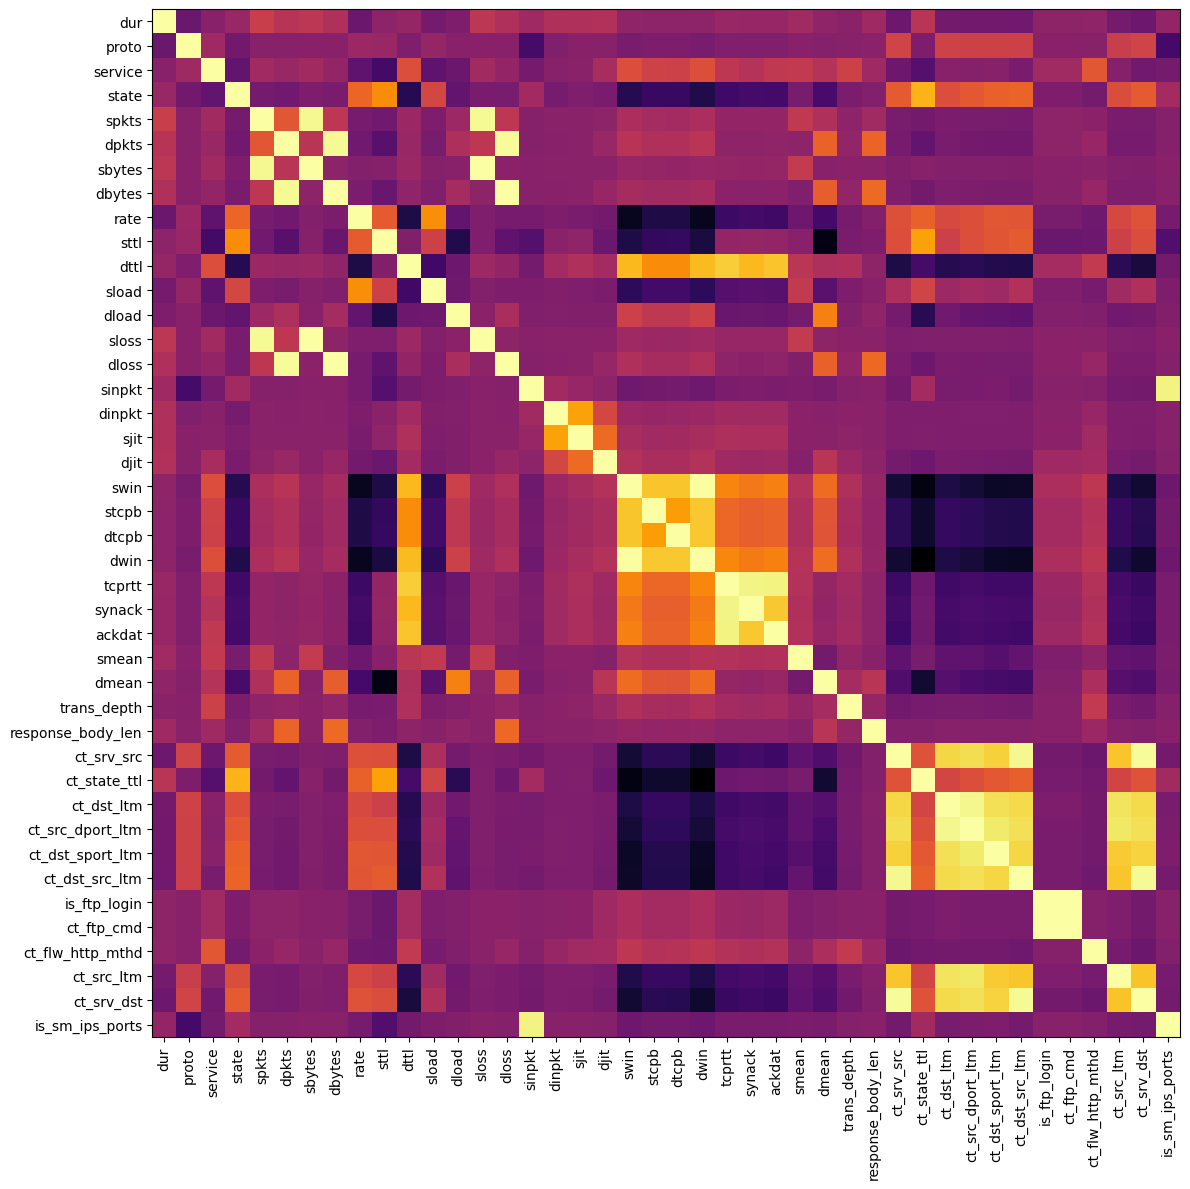

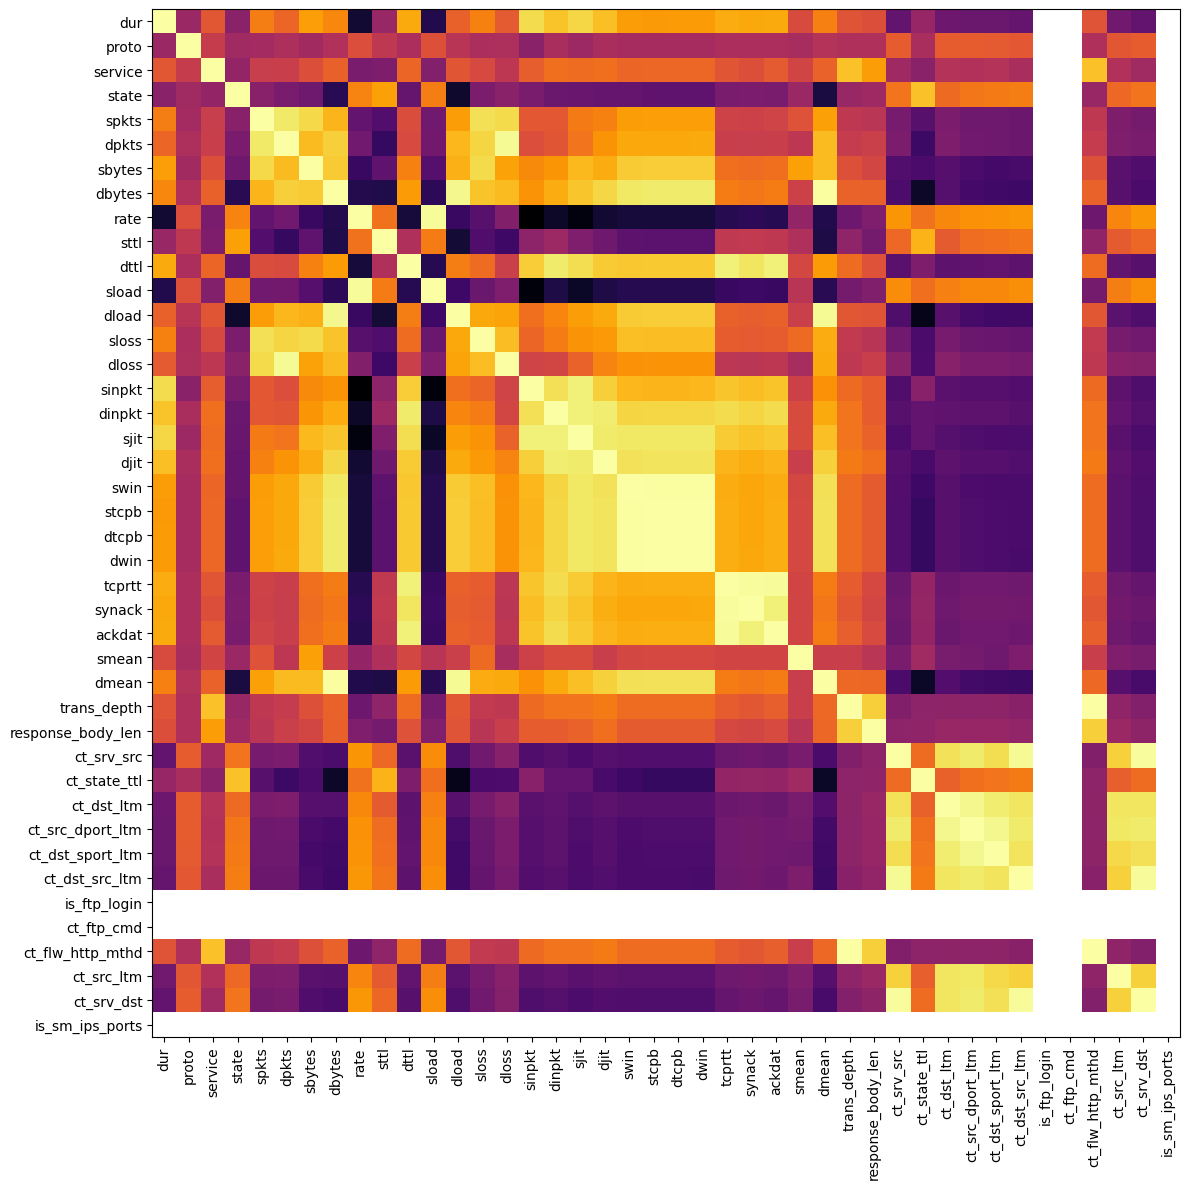

In [18]:
def print_correlation_matrix(data: pd.DataFrame):
    cols_cat = data.select_dtypes(exclude=[np.number]).columns
    if cols_cat.any():
        for col in cols_cat:
            data[col] = data[col].astype('category')
            data[col] = data[col].cat.codes
    corr = data.corr()
    
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.matshow(corr, cmap='inferno')
    n = range(0, corr.columns.size)
    ax.set_xticks(n)
    ax.set_yticks(n)
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)
    ax.xaxis.set_ticks_position('bottom')
    plt.tight_layout()
    plt.show()

    return corr

raw_corr  = print_correlation_matrix(rawdata)
proc_corr = print_correlation_matrix(processed_data)